# Домашнее задание к семинару 12 (HW12)

Тема: временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU.

HW12 выполняется в личном репозитории студента (на основе шаблона курса) в папке `homeworks/HW12/`.

---

## 1. Цель

Закрепить:

- отличие временных рядов от обычных табличных данных с точки зрения валидации;
- практику корректного `temporal split` вместо случайного `random split`;
- построение лаговых, rolling- и календарных признаков;
- сравнение простых baseline-подходов с рекуррентной моделью;
- аккуратное оформление результата: один ноутбук, короткий отчёт, артефакты эксперимента.

---

## 2. Задание

### 2.1. Структура для HW12 (обязательно)

1. В корне репозитория должна быть папка `homeworks/` (создать, если её ещё нет).
2. Внутри `homeworks/` создать папку `HW12/`.
3. В папке `homeworks/HW12/` создать:

- основной ноутбук: `HW12.ipynb`
- отчёт: `report.md`
- папку для артефактов: `artifacts/`
  - рекомендуется внутри `artifacts/` завести подпапку `figures/` для графиков

> Имена папок и файлов должны быть строго такими, как указано (регистр важен).

---

### 2.2. Датасет для домашней работы

Используйте предоставленный преподавателем CSV-файл:

- `S12-hw-dataset.csv`

Предполагается, что в датасете есть как минимум:

- колонка `date` — временная метка;
- колонка `target` — прогнозируемый числовой ряд.

Допустимо, что в файле будут и дополнительные внешние признаки. Их можно использовать, но обязательная часть домашней работы должна корректно решаться уже на основе самого ряда `target` и производных от него признаков.

Требования к данным:

- использовать **хронологический** порядок наблюдений;
- не перемешивать строки перед разбиением;
- привести колонку `date` к типу datetime и отсортировать данные по времени;
- в ноутбуке показать sanity-check по данным: размер датасета, диапазон дат, наличие/отсутствие пропусков, базовый график ряда;
- если в датасете есть пропуски, выбранный способ обработки нужно кратко объяснить.

Важно:

- использовать `random split` в основной постановке **нельзя**;
- test-часть должна использоваться только для финальной проверки после выбора лучшей модели по `validation`.

---

### 2.3. Содержание ноутбука `HW12.ipynb` (обязательно)

В ноутбуке `homeworks/HW12/HW12.ipynb` реализуйте и покажите следующие блоки.

#### 2.3.1. Импорты, seed и среда

1) Импортировать библиотеки: `pandas`, `numpy`, `matplotlib`, `sklearn`, `torch` (и всё, что нужно по делу).
2) Зафиксировать seed (минимум `random`, `numpy`, `torch`).
3) Определить устройство (`cuda` при наличии, иначе `cpu`) и использовать его последовательно.

In [4]:
# Базовые библиотеки для генерации данных, анализа и обучения простых моделей.
import math
import os, csv, json
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# PyTorch для построения и обучения нейросетей
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Делаем графики и табличный вывод чуть удобнее для демонстрации в ноутбуке.
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [5]:
# Фиксация seed
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
SEED = 42
set_seed(SEED)

In [6]:
# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("seed:", SEED)

device: cpu
seed: 42


#### 2.3.2. Данные и первичный анализ

1) Загрузить `S12-hw-dataset.csv`.
2) Привести `date` к datetime и отсортировать строки по времени.
3) Показать:
   - число наблюдений;
   - диапазон дат;
   - число пропусков по колонкам;
   - базовый график временного ряда.
4) Кратко прокомментировать ряд: тренд, сезонность, выбросы, возможную нестационарность.

In [7]:
# 1) Загрузка датасета
DATA_PATH = "./data/S12-hw-dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [8]:
# 2) Приведение date к datetime и сортировка по времени
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

In [9]:
# 3) Sanity-check по данным
print("Число наблюдений:", len(df))
print("Диапазон дат:", df["date"].min(), "->", df["date"].max())
print("\nПропуски по колонкам:")
print(df.isna().sum())

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64


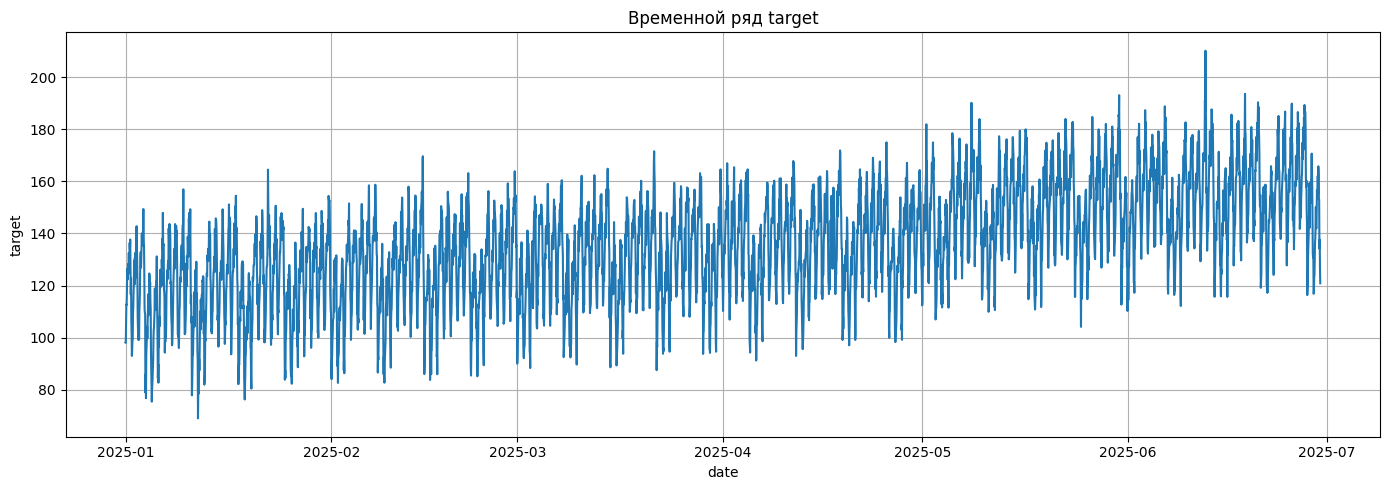

In [10]:
# Базовый график временного ряда
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["target"])
plt.title("Временной ряд target")
plt.xlabel("date")
plt.ylabel("target")
plt.grid(True)
plt.tight_layout()
plt.show()

4) Краткий комментарий ряда: тренд, сезонность, выбросы, возможную нестационарность.
- В датасете 4320 наблюдений за период с 2025-01-01 00:00:00 по 2025-06-29 23:00:00.
- Пропусков в колонках `date` и `target` нет, поэтому на этом этапе дополнительная обработка пропусков не требуется.
- По графику видно, что ряд имеет выраженный восходящий тренд: средний уровень `target` со временем увеличивается.
- Также заметна регулярная повторяющаяся структура, то есть у ряда, вероятно, есть сезонность. По виду графика она похожа на короткий циклический паттерн, что может соответствовать суточной или другой регулярной периодичности.
- В ряду есть отдельные локальные всплески и провалы, которые можно интерпретировать как выбросы или эпизоды повышенной вариативности.
- Ряд, скорее всего, нестационарен, потому что его средний уровень меняется со временем, а разброс значений во второй половине периода визуально тоже выглядит немного выше.
- Поэтому для дальнейшего анализа важно использовать `temporal split`, а также лаговые, rolling- и календарные признаки.

#### 2.3.3. Корректный temporal split

1) Разбить данные на `train / validation / test` **по времени**.
2) Явно показать границы split.
3) Визуально отобразить, какие участки ряда относятся к `train`, `validation`, `test`.
4) Кратко объяснить, почему `random split` для данной задачи некорректен.

In [11]:
# Конфиг split
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15

# 1) Разбиение по времени: train / validation / test
def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    n = len(df)

    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [12]:
# Применяем temporal split
train_df, val_df, test_df = temporal_split(df)

print("train size:", len(train_df))
print("val size  :", len(val_df))
print("test size :", len(test_df))

train size: 3024
val size  : 648
test size : 648


In [13]:
# 2) Границы split по времени
print("TRAIN:")
print(" ", train_df["date"].min(), "->", train_df["date"].max())

print("VALIDATION:")
print(" ", val_df["date"].min(), "->", val_df["date"].max())

print("TEST:")
print(" ", test_df["date"].min(), "->", test_df["date"].max())

TRAIN:
  2025-01-01 00:00:00 -> 2025-05-06 23:00:00
VALIDATION:
  2025-05-07 00:00:00 -> 2025-06-02 23:00:00
TEST:
  2025-06-03 00:00:00 -> 2025-06-29 23:00:00


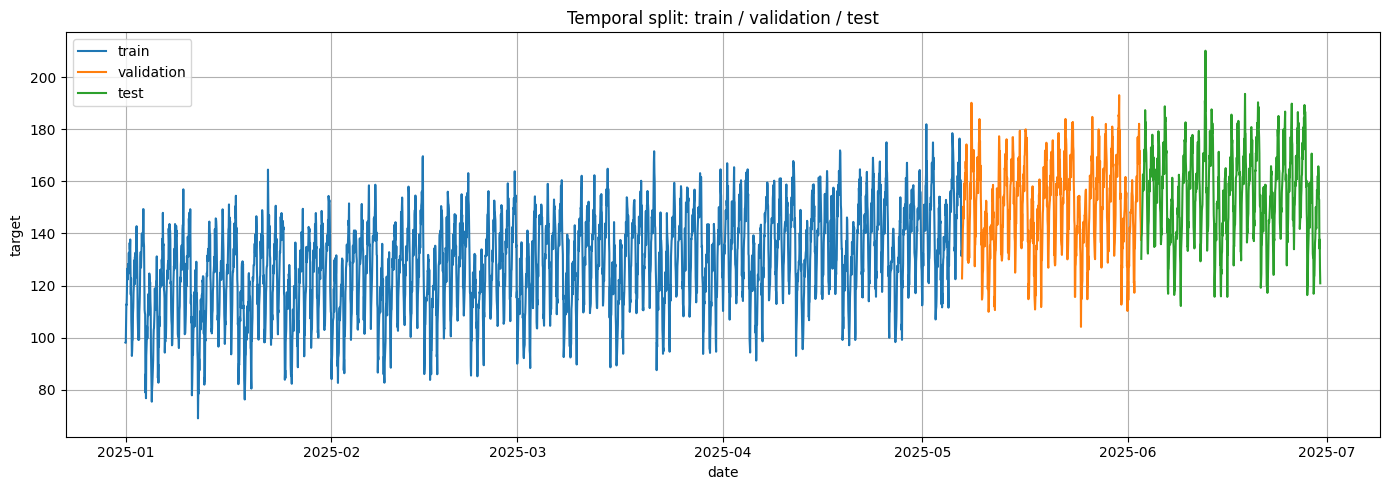

In [14]:
# 3) Визуализация train / validation / test
plt.figure(figsize=(14, 5))

plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="validation")
plt.plot(test_df["date"], test_df["target"], label="test")

plt.title("Temporal split: train / validation / test")
plt.xlabel("date")
plt.ylabel("target")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

4) Краткий комментарий:
- Данные разбиты на `train / validation / test` строго по времени, без перемешивания строк.
- Размеры частей получились такими: `train = 3024`, `validation = 648`, `test = 648`.
- Временные границы split:
  - `train`: с `2025-01-01 00:00:00` по `2025-05-06 23:00:00`
  - `validation`: с `2025-05-07 00:00:00` по `2025-06-02 23:00:00`
  - `test`: с `2025-06-03 00:00:00` по `2025-06-29 23:00:00`
- На графике видно, что `train` соответствует более раннему периоду ряда, `validation` — следующему по времени участку, а `test` — самому позднему.
- Такой split корректен для задачи прогнозирования, потому что модель должна обучаться на прошлом и проверяться на будущем.
- `random split` для этой задачи некорректен, так как он смешивает ранние и поздние наблюдения, создаёт риск утечки информации из будущего и даёт слишком оптимистичную оценку качества.

### Почему random split некорректен для временного ряда

Для задачи прогнозирования временного ряда нельзя использовать `random split`, потому что модель должна обучаться на прошлом и проверяться на будущем.

Если перемешать строки случайно, то в train могут попасть наблюдения из более поздних моментов времени, чем в validation и test. Это создаёт утечку информации из будущего и даёт слишком оптимистичную оценку качества.

Поэтому в HW12 используется только хронологический `temporal split`: сначала `train`, затем `validation`, затем `test`.

#### 2.3.4. Признаки для baseline-моделей

Построить и использовать минимум такие признаки:

- `lag_1`
- `lag_7`
- `lag_14`
- `rolling_mean_7`
- `rolling_std_7`
- календарные признаки из даты (минимум день недели; дополнительные — по желанию)

Важно:
- rolling- и lag-признаки должны строиться без утечки информации из будущего;
- если используется масштабирование, его нужно обучать только на `train`.

In [15]:
# Календарные признаки из даты

def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7.0)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7.0)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12.0)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12.0)

    return out

In [16]:
# Lag признаки из прошлого

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()
    out["lag_1"] = out[target_col].shift(1)
    out["lag_7"] = out[target_col].shift(7)
    out["lag_14"] = out[target_col].shift(14)

    return out

In [17]:
# Rolling-признаки только по прошлому
# Сначала сдвигаем target на 1, потом считаем rolling

def add_rolling_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()
    shifted = out[target_col].shift(1)
    out["rolling_mean_7"] = shifted.rolling(window=7).mean()
    out["rolling_std_7"] = shifted.rolling(window=7).std()

    return out

In [18]:
# Собираем все признаки вместе

features_df = df.copy()
features_df = add_calendar_features(features_df)
features_df = add_lag_features(features_df, target_col="target")
features_df = add_rolling_features(features_df, target_col="target")
features_df.head(15)

,date,target,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 00:00:00,98.14,2,1,0.974928,-0.222521,0.5,0.866025,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 01:00:00,98.07,2,1,0.974928,-0.222521,0.5,0.866025,98.14,NaN,NaN,NaN,NaN
2,2025-01-01 02:00:00,104.70,2,1,0.974928,-0.222521,0.5,0.866025,98.07,NaN,NaN,NaN,NaN
3,2025-01-01 03:00:00,112.81,2,1,0.974928,-0.222521,0.5,0.866025,104.70,NaN,NaN,NaN,NaN
4,2025-01-01 04:00:00,112.62,2,1,0.974928,-0.222521,0.5,0.866025,112.81,NaN,NaN,NaN,NaN
5,2025-01-01 05:00:00,117.29,2,1,0.974928,-0.222521,0.5,0.866025,112.62,NaN,NaN,NaN,NaN
6,2025-01-01 06:00:00,126.50,2,1,0.974928,-0.222521,0.5,0.866025,117.29,NaN,NaN,NaN,NaN
7,2025-01-01 07:00:00,126.01,2,1,0.974928,-0.222521,0.5,0.866025,126.50,98.14,NaN,110.018571,10.418147
8,2025-01-01 08:00:00,122.38,2,1,0.974928,-0.222521,0.5,0.866025,126.01,98.07,NaN,114.000000,10.447405
9,2025-01-01 09:00:00,128.28,2,1,0.974928,-0.222521,0.5,0.866025,122.38,104.70,NaN,117.472857,8.030400


In [19]:
# Признаки для baseline-моделей

feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "dayofweek",
    "dow_sin",
    "dow_cos",
    "month",
    "month_sin",
    "month_cos",
]
target_col = "target"
print("feature_cols:", feature_cols)
print("target_col:", target_col)

feature_cols: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek', 'dow_sin', 'dow_cos', 'month', 'month_sin', 'month_cos']
target_col: target


In [20]:
# После lag/rolling в начале ряда NaN 
# Удаляем только те строки, где не хватает признаков

features_df = features_df.dropna(subset=feature_cols).reset_index(drop=True)
print("Размер features_df после dropna:", len(features_df))
features_df[["date", "target"] + feature_cols].head()

Размер features_df после dropna: 4306


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,dow_sin,dow_cos,month,month_sin,month_cos
0,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2,0.974928,-0.222521,1,0.5,0.866025
1,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2,0.974928,-0.222521,1,0.5,0.866025
2,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2,0.974928,-0.222521,1,0.5,0.866025
3,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2,0.974928,-0.222521,1,0.5,0.866025
4,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2,0.974928,-0.222521,1,0.5,0.866025


In [21]:
# Sanity-check по признакам

print(features_df[feature_cols].isna().sum())
features_df[["date", "target", "lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "dayofweek"]].head(10)

lag_1             0
lag_7             0
lag_14            0
rolling_mean_7    0
rolling_std_7     0
dayofweek         0
dow_sin           0
dow_cos           0
month             0
month_sin         0
month_cos         0
dtype: int64


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek
0,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2
1,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2
2,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2
3,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2
4,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2
5,2025-01-01 19:00:00,116.59,126.32,132.63,117.29,131.545714,4.913244,2
6,2025-01-01 20:00:00,122.83,116.59,125.04,126.50,129.254286,7.422746,2
7,2025-01-01 21:00:00,106.54,122.83,128.87,126.01,128.938571,7.674595,2
8,2025-01-01 22:00:00,101.72,106.54,136.40,122.38,125.748571,11.429896,2
9,2025-01-01 23:00:00,93.04,101.72,133.85,128.28,120.794286,13.391289,2


Краткий комментарий:

- Для baseline-моделей успешно построены лаговые признаки `lag_1`, `lag_7`, `lag_14`, rolling-признаки `rolling_mean_7`, `rolling_std_7` и календарные признаки из даты.
- После удаления начальных строк с недостаточной историей получен датафрейм `features_df` размером 4306 наблюдений.
- Проверка показала, что в итоговых признаках из списка `feature_cols` пропусков нет, значит данные готовы для дальнейшего использования в baseline-моделях.
- По первым строкам видно, что лаговые признаки действительно содержат прошлые значения ряда, а rolling-статистики считаются по предыдущим наблюдениям, а не по будущим.
- Это означает, что признаки построены корректно и без утечки информации из будущего.

### Возможные утечки данных в HW12

Во временных рядах утечка данных возникает, если в модель попадает информация из будущего.

В этой работе утечки избегаются так:
- используется только `temporal split`, без перемешивания строк;
- lag- и rolling-признаки строятся только из прошлых значений ряда;
- `StandardScaler` обучается только на `train`, а к `validation` и `test` применяется только `transform`.

#### 2.3.5. Оконное представление для GRU

1) Подготовить последовательности фиксированной длины `window_size`.
2) Реализовать `Dataset` / `DataLoader` для задачи прогноза следующего значения ряда.
3) При необходимости выполнить масштабирование таргета или входных последовательностей с корректным `fit` только на `train`.

In [22]:
# Оконное представление для GRU

series_col = "target"
train_series = train_df[[series_col]].copy()
val_series = val_df[[series_col]].copy()
test_series = test_df[[series_col]].copy()

In [23]:
# Масштабирование target только по train
# Важно: fit только на train, validation/test — только transform

target_scaler = StandardScaler()
target_scaler.fit(train_series)

train_scaled = target_scaler.transform(train_series).astype(np.float32)
val_scaled = target_scaler.transform(val_series).astype(np.float32)
test_scaled = target_scaler.transform(test_series).astype(np.float32)

print("train_scaled shape:", train_scaled.shape)
print("val_scaled shape  :", val_scaled.shape)
print("test_scaled shape :", test_scaled.shape)

train_scaled shape: (3024, 1)
val_scaled shape  : (648, 1)
test_scaled shape : (648, 1)


In [24]:
# Длина окна последовательности

window_size = 24
print("window_size:", window_size)

window_size: 24


In [25]:
# Перевод ряда в оконное представление 

def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(window_size, len(series_2d)):
        X.append(series_2d[i - window_size:i])
        y.append(series_2d[i])
    X = np.stack(X).astype(np.float32)
    y = np.stack(y).astype(np.float32)

    return X, y

In [26]:
# Окна для train / validation / test

X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_val shape  :", X_val.shape,   "| y_val shape  :", y_val.shape)
print("X_test shape :", X_test.shape,  "| y_test shape :", y_test.shape)

X_train shape: (3000, 24, 1) | y_train shape: (3000, 1)
X_val shape  : (624, 24, 1) | y_val shape  : (624, 1)
X_test shape : (624, 24, 1) | y_test shape : (624, 1)


In [27]:
# Dataset для forecasting 

class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [28]:
# Dataset-объекты

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

print("len(train_ds):", len(train_ds))
print("len(val_ds)  :", len(val_ds))
print("len(test_ds) :", len(test_ds))

len(train_ds): 3000
len(val_ds)  : 624
len(test_ds) : 624


In [60]:
# DataLoader 

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print("batch_size:", batch_size)

batch_size: 64


In [30]:
# Sanity-check по одному batch

xb, yb = next(iter(train_loader))

print("xb shape:", xb.shape)
print("yb shape:", yb.shape)
print("xb dtype:", xb.dtype)
print("yb dtype:", yb.dtype)

xb shape: torch.Size([64, 24, 1])
yb shape: torch.Size([64, 1])
xb dtype: torch.float32
yb dtype: torch.float32


Краткий комментарий:

- Для рекуррентной модели ряд `target` был переведён в оконное представление фиксированной длины `window_size = 24`.
- Масштабирование выполнено корректно: `StandardScaler` обучен только на `train`-части (`3024` наблюдения), после чего применён к `validation` и `test` без дополнительного `fit`.
- После построения окон получены выборки:
  - `X_train`: `(3000, 24, 1)`, `y_train`: `(3000, 1)`
  - `X_val`: `(624, 24, 1)`, `y_val`: `(624, 1)`
  - `X_test`: `(624, 24, 1)`, `y_test`: `(624, 1)`
- Это означает, что каждый объект для GRU содержит последовательность из 24 предыдущих значений ряда, а target — следующее значение после этого окна.
- Для работы в PyTorch реализован `TimeSeriesDataset`, и созданы `DataLoader` для `train / validation / test`.
- Проверка одного batch показала, что данные имеют корректную форму для GRU: `xb` имеет размер `torch.Size([64, 24, 1])`, а `yb` — `torch.Size([64, 1])`; тип данных в обоих случаях `torch.float32`.

#### 2.3.6. Базовые функции обучения и оценки

Для RNN-части реализовать и использовать:

- цикл обучения по эпохам;
- вычисление метрик на `validation`;
- сохранение лучшей модели по валидационному критерию;
- логирование истории обучения.

Для всех подходов обеспечить сопоставимую оценку на `validation`, а затем один раз — на `test` для лучшего варианта.

---

In [31]:
# Базовые функции обучения и оценки

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    eps = 1e-8
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100.0

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    eps = 1e-8
    return np.mean(2.0 * np.abs(y_pred - y_true) / np.maximum(denom, eps)) * 100.0

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
    }

In [32]:
# GRU-модель для прогноза следующего значения — как в demo-02

class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.gru(x)
        last_hidden = h_n[-1]
        y_hat = self.fc(last_hidden)
        return y_hat

In [33]:
# Один train epoch 

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_count = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / total_count

In [34]:
# Loss на validation / test 

@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_count = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / total_count

In [35]:
# Предсказания модели 

@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds = []
    targets = []
    for xb, yb in loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        preds.append(pred)
        targets.append(yb.numpy())
    preds = np.vstack(preds)
    targets = np.vstack(targets)

    return preds, targets

In [36]:
# Возврат в исходный масштаб ряда

def inverse_scale(arr_2d: np.ndarray, scaler: StandardScaler):
    return scaler.inverse_transform(arr_2d)

In [37]:
# Метрики на validation / test в исходном масштабе ряда

def evaluate_metrics(model, loader, scaler, device):
    pred_scaled, y_scaled = predict_model(model, loader, device)
    pred = inverse_scale(pred_scaled, scaler).ravel()
    y_true = inverse_scale(y_scaled, scaler).ravel()

    return regression_metrics(y_true, pred)

In [38]:
# Полный цикл обучения с history и best_state 

def fit_model(model, train_loader, val_loader, scaler, epochs=12, lr=1e-3, device=device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mae": [],
        "val_rmse": [],
        "val_mape": [],
        "val_smape": [],
    }
    best_val_loss = float("inf")
    best_state = None
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)
        val_metrics = evaluate_metrics(model, val_loader, scaler, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_metrics["MAE"])
        history["val_rmse"].append(val_metrics["RMSE"])
        history["val_mape"].append(val_metrics["MAPE"])
        history["val_smape"].append(val_metrics["sMAPE"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f} | "
            f"val_MAE={val_metrics['MAE']:.4f} | "
            f"val_RMSE={val_metrics['RMSE']:.4f} | "
            f"val_MAPE={val_metrics['MAPE']:.2f} | "
            f"val_sMAPE={val_metrics['sMAPE']:.2f}"
        )
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_loss

In [40]:
# Быстрый sanity-check

set_seed(SEED)
gru_model = GRUForecaster(input_size=1, hidden_size=64, num_layers=2).to(device)
gru_model, gru_history, best_val_loss = fit_model(
    gru_model,
    train_loader,
    val_loader,
    target_scaler,
    epochs=3,
    lr=1e-3,
    device=device,
)
print("best_val_loss:", best_val_loss)

Epoch 01 | train_loss=0.515586 | val_loss=0.392352 | val_MAE=9.6080 | val_RMSE=11.5765 | val_MAPE=6.25 | val_sMAPE=6.51
Epoch 02 | train_loss=0.162259 | val_loss=0.174294 | val_MAE=6.1181 | val_RMSE=7.7158 | val_MAPE=4.16 | val_sMAPE=4.19
Epoch 03 | train_loss=0.156506 | val_loss=0.217341 | val_MAE=7.0347 | val_RMSE=8.6161 | val_MAPE=4.68 | val_sMAPE=4.80
best_val_loss: 0.1742939116098942


In [41]:
# History после короткого запуска
gru_history

{'train_loss': [0.5155858105421066, 0.16225876291592917, 0.1565057212114334],
 'val_loss': [0.39235241825763995, 0.1742939116098942, 0.2173406095840992],
 'val_mae': [9.608016967773438, 6.118115425109863, 7.034725666046143],
 'val_rmse': [11.576476192062533, 7.715771057798269, 8.61605858000638],
 'val_mape': [np.float32(6.2544465),
  np.float32(4.1633425),
  np.float32(4.6783223)],
 'val_smape': [np.float32(6.5086894),
  np.float32(4.1882796),
  np.float32(4.7952437)]}

Краткий комментарий:

- Базовые функции обучения и оценки для RNN-части работают корректно: модель обучается по эпохам, считается `train_loss`, `val_loss`, а также валидационные метрики `MAE`, `RMSE`, `MAPE`,`sMAPE.
- В коротком тестовом запуске видно, что после первой эпохи качество заметно улучшилось: и `train_loss`, и `val_loss` существенно уменьшились.
- Лучший результат на `validation` был получен на 2-й эпохе: `best_val_loss ≈ 0.1743`, `val_MAE ≈ 6.12`, `val_RMSE ≈ 7.72`, `val_MAPE ≈ 4.16`, `val_sMAPE ≈ 4.19`
- На 3-й эпохе валидационные метрики немного ухудшились по сравнению со 2-й, хотя `train_loss` продолжил снижаться. Это нормальный сигнал, что лучшую модель нужно выбирать именно по валидационному критерию, а не по последней эпохе.
- История обучения логируется корректно: в `gru_history` сохранены `train_loss`, `val_loss`, `val_mae`, `val_rmse`, `val_mape`.
- Таким образом, базовый каркас для `GRUForecaster` готов: модель можно обучать, сравнивать по `validation` и сохранять лучшую версию для дальнейшей финальной проверки на `test`.

## 3. Эксперименты

Все результаты прогонов фиксируются в `artifacts/runs.csv` (см. раздел 4).

### 3.1. Обязательные эксперименты

Нужно провести 4 эксперимента.

- **B1 (`naive-last`)**: наивный baseline, где прогноз равен последнему известному значению.
- **B2 (`moving-average`)**: baseline на основе скользящего среднего по окну разумного размера.
- **B3 (`ridge-lag-features`)**: `Ridge` (или `LinearRegression`) на лаговых, rolling- и календарных признаках.
- **R1 (`gru-forecast`)**: `GRU` на оконном представлении ряда.

Эксперимент = фиксированный конфиг + обучение/оценка + запись результата в `runs.csv`.

Требования:

- основное сравнение делается на `validation`;
- лучшая модель выбирается по `best_val_mae` или другому явно указанному критерию из отчёта;
- test используется **один раз**: только для финальной оценки выбранного лучшего подхода;
- сравнение должно быть корректным: фиксированный seed, один и тот же split, сопоставимая постановка задачи.

Важно:

- в B1 и B2 не нужно обучать нейросети;
- в B3 нельзя использовать признаки, содержащие информацию из будущего;
- в R1 достаточно одной архитектуры `GRU`; обязательного сравнения с `LSTM` нет.

### 3.2. Метрики

Для экспериментов нужно считать минимум:

- `MAE`
- `RMSE`
- `MAPE`

Дополнительно приветствуются:

- `sMAPE`
- график ошибок/остатков

---

In [42]:
# Границы основного temporal split

train_start = train_df["date"].min()
train_end = train_df["date"].max()

val_start = val_df["date"].min()
val_end = val_df["date"].max()

test_start = test_df["date"].min()
test_end = test_df["date"].max()

In [43]:
# Feature-based split с теми же временными границами

train_feat = features_df[(features_df["date"] >= train_start) & (features_df["date"] <= train_end)].copy()
val_feat = features_df[(features_df["date"] >= val_start) & (features_df["date"] <= val_end)].copy()
test_feat = features_df[(features_df["date"] >= test_start) & (features_df["date"] <= test_end)].copy()

print("train_feat size:", len(train_feat))
print("val_feat size  :", len(val_feat))
print("test_feat size :", len(test_feat))

train_feat size: 3010
val_feat size  : 648
test_feat size : 648


In [44]:
# X / y для B3

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

In [45]:
# B1 (naive-last): прогноз = последнее известное значение

val_true_b = y_val.to_numpy()
val_pred_b1 = val_feat["lag_1"].to_numpy()

b1_val_metrics = regression_metrics(val_true_b, val_pred_b1)
b1_val_metrics

{'MAE': 6.444814814814815,
 'RMSE': 8.20102295260389,
 'MAPE': np.float64(4.39792166354992),
 'sMAPE': np.float64(4.363947894795011)}

In [61]:
# B2 (moving-average)
# Прогноз = moving average = rolling_mean_7

val_true_b2 = y_val.to_numpy()
val_pred_b2 = val_feat["rolling_mean_7"].to_numpy()

b2_val_metrics = regression_metrics(val_true_b2, val_pred_b2)
b2_val_metrics

{'MAE': 12.702012786596118,
 'RMSE': 15.217644526713752,
 'MAPE': np.float64(8.81686403093607),
 'sMAPE': np.float64(8.614741102603329)}

In [71]:
# B3 (ridge-lag-features)
# Масштабирование признаков только по train
# Важно: fit только на train, validation/test — только transform

feature_scaler = StandardScaler()
feature_scaler.fit(X_train)

X_train_scaled = feature_scaler.transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled = feature_scaler.transform(X_test)

In [48]:
# Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [49]:
# Validation для B3

val_pred_b3 = ridge.predict(X_val_scaled)

b3_val_metrics = regression_metrics(val_true_b, val_pred_b3)
b3_val_metrics

{'MAE': 6.4451732544070826,
 'RMSE': 7.947281720831049,
 'MAPE': np.float64(4.3092155927946765),
 'sMAPE': np.float64(4.379456125985638)}

In [51]:
# R1 (gru-forecast)

set_seed(SEED)
gru_epochs = 20
gru_lr = 1e-3
gru_model = GRUForecaster(input_size=1, hidden_size=64, num_layers=2).to(device)
gru_model, gru_history, best_val_loss = fit_model(
    gru_model,
    train_loader,
    val_loader,
    target_scaler,
    epochs=gru_epochs,
    lr=gru_lr,
    device=device,
)
print("best_val_loss:", best_val_loss)

Epoch 01 | train_loss=0.515586 | val_loss=0.392352 | val_MAE=9.6080 | val_RMSE=11.5765 | val_MAPE=6.25 | val_sMAPE=6.51
Epoch 02 | train_loss=0.162259 | val_loss=0.174294 | val_MAE=6.1181 | val_RMSE=7.7158 | val_MAPE=4.16 | val_sMAPE=4.19
Epoch 03 | train_loss=0.156506 | val_loss=0.217341 | val_MAE=7.0347 | val_RMSE=8.6161 | val_MAPE=4.68 | val_sMAPE=4.80
Epoch 04 | train_loss=0.148701 | val_loss=0.173162 | val_MAE=6.1578 | val_RMSE=7.6907 | val_MAPE=4.16 | val_sMAPE=4.21
Epoch 05 | train_loss=0.146636 | val_loss=0.202528 | val_MAE=6.7623 | val_RMSE=8.3173 | val_MAPE=4.53 | val_sMAPE=4.63
Epoch 06 | train_loss=0.146565 | val_loss=0.204161 | val_MAE=6.7757 | val_RMSE=8.3507 | val_MAPE=4.55 | val_sMAPE=4.65
Epoch 07 | train_loss=0.144329 | val_loss=0.226651 | val_MAE=7.1659 | val_RMSE=8.7987 | val_MAPE=4.76 | val_sMAPE=4.88
Epoch 08 | train_loss=0.142196 | val_loss=0.190346 | val_MAE=6.4596 | val_RMSE=8.0632 | val_MAPE=4.37 | val_sMAPE=4.45
Epoch 09 | train_loss=0.131160 | val_loss=0.214

In [52]:
# Validation-предсказания для R1 в исходном масштабе

r1_val_pred_scaled, r1_val_true_scaled = predict_model(gru_model, val_loader, device)
r1_val_pred = inverse_scale(r1_val_pred_scaled, target_scaler).ravel()
r1_val_true = inverse_scale(r1_val_true_scaled, target_scaler).ravel()
r1_val_metrics = regression_metrics(r1_val_true, r1_val_pred)
r1_val_metrics

{'MAE': 5.546346187591553,
 'RMSE': 7.186886703199038,
 'MAPE': np.float32(3.7263062),
 'sMAPE': np.float32(3.77178)}

In [53]:
# Сравнение на validation

val_results = pd.DataFrame([
    {
        "experiment_id": "B1",
        "model": "naive-last",
        "MAE": b1_val_metrics["MAE"],
        "RMSE": b1_val_metrics["RMSE"],
        "MAPE": b1_val_metrics["MAPE"],
        "sMAPE": b1_val_metrics["sMAPE"],
    },
    {
        "experiment_id": "B2",
        "model": "moving-average",
        "MAE": b2_val_metrics["MAE"],
        "RMSE": b2_val_metrics["RMSE"],
        "MAPE": b2_val_metrics["MAPE"],
        "sMAPE": b2_val_metrics["sMAPE"],
    },
    {
        "experiment_id": "B3",
        "model": "ridge-lag-features",
        "MAE": b3_val_metrics["MAE"],
        "RMSE": b3_val_metrics["RMSE"],
        "MAPE": b3_val_metrics["MAPE"],
        "sMAPE": b3_val_metrics["sMAPE"],
    },
    {
        "experiment_id": "R1",
        "model": "gru-forecast",
        "MAE": r1_val_metrics["MAE"],
        "RMSE": r1_val_metrics["RMSE"],
        "MAPE": r1_val_metrics["MAPE"],
        "sMAPE": r1_val_metrics["sMAPE"],
    },
]).sort_values("MAE").reset_index(drop=True)

val_results

,experiment_id,model,MAE,RMSE,MAPE,sMAPE
0,R1,gru-forecast,5.546346,7.186887,3.726306,3.771780
1,B1,naive-last,6.444815,8.201023,4.397922,4.363948
2,B3,ridge-lag-features,6.445173,7.947282,4.309216,4.379456
3,B2,moving-average,12.702013,15.217645,8.816864,8.614741


In [54]:
# Лучшая модель выбирается по best_val_mae

best_experiment_id = val_results.iloc[0]["experiment_id"]
best_model_name = val_results.iloc[0]["model"]
print("best_experiment_id:", best_experiment_id)
print("best_model_name   :", best_model_name)

best_experiment_id: R1
best_model_name   : gru-forecast


In [68]:
# Test-метрики для B1

test_true_b = y_test.to_numpy()

test_pred_b1 = test_feat["lag_1"].to_numpy()
b1_test_metrics = regression_metrics(test_true_b, test_pred_b1)
b1_test_metrics


{'MAE': 6.342438271604938,
 'RMSE': 8.05906919540317,
 'MAPE': np.float64(4.1485481293996385),
 'sMAPE': np.float64(4.123187161241681)}

In [69]:
# Test-метрики для B2 
test_true_b2 = y_test.to_numpy()
test_pred_b2 = test_feat["rolling_mean_7"].to_numpy()
b2_test_metrics = regression_metrics(test_true_b2, test_pred_b2)

b2_test_metrics

{'MAE': 12.74030864197531,
 'RMSE': 15.238698825884764,
 'MAPE': np.float64(8.549006329583134),
 'sMAPE': np.float64(8.347675382278718)}

In [70]:
# Test-метрики для B3

test_pred_b3 = ridge.predict(X_test_scaled)
b3_test_metrics = regression_metrics(test_true_b, test_pred_b3)

b3_test_metrics

{'MAE': 5.431345437408328,
 'RMSE': 6.939907014683554,
 'MAPE': np.float64(3.531630481518591),
 'sMAPE': np.float64(3.540724984918354)}

In [63]:
# Test-метрики для R1

r1_test_pred_scaled, r1_test_true_scaled = predict_model(gru_model, test_loader, device)

r1_test_pred = inverse_scale(r1_test_pred_scaled, target_scaler).ravel()
r1_test_true = inverse_scale(r1_test_true_scaled, target_scaler).ravel()

r1_test_metrics = regression_metrics(r1_test_true, r1_test_pred)
r1_test_metrics

{'MAE': 6.566404819488525,
 'RMSE': 8.319039662030558,
 'MAPE': np.float32(4.209355),
 'sMAPE': np.float32(4.2907376)}

In [57]:
# Финальная test-оценка только для лучшего подхода

if best_experiment_id == "B1":
    best_test_metrics = b1_test_metrics
elif best_experiment_id == "B2":
    best_test_metrics = b2_test_metrics
elif best_experiment_id == "B3":
    best_test_metrics = b3_test_metrics
elif best_experiment_id == "R1":
    best_test_metrics = r1_test_metrics
else:
    raise ValueError(f"Unknown best_experiment_id: {best_experiment_id}")

best_test_metrics

{'MAE': 6.566404819488525,
 'RMSE': 8.319039662030558,
 'MAPE': np.float32(4.209355),
 'sMAPE': np.float32(4.2907376)}

In [58]:
# График прогноза и остатков

def plot_forecast_and_residuals(dates, y_true, y_pred, title_prefix=""):
    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(dates, y_true, label="true")
    axes[0].plot(dates, y_pred, label="pred")
    axes[0].set_title(f"{title_prefix} | true vs pred")
    axes[0].set_xlabel("date")
    axes[0].set_ylabel("target")
    axes[0].grid(True)
    axes[0].legend()
    
    axes[1].plot(dates, residuals, label="residuals")
    axes[1].axhline(0.0, linestyle="--")
    axes[1].set_title(f"{title_prefix} | residuals")
    axes[1].set_xlabel("date")
    axes[1].set_ylabel("y_true - y_pred")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

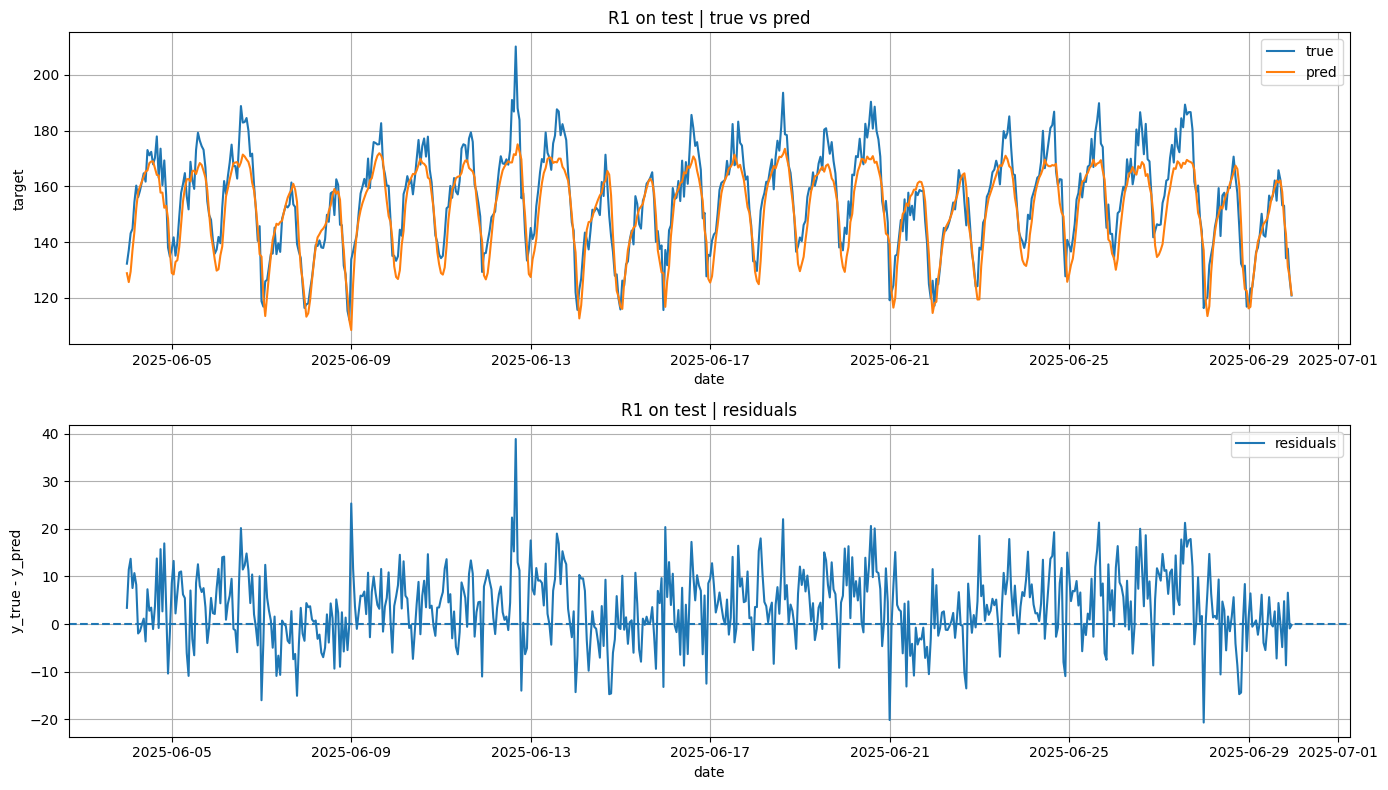

In [59]:
# Построить график для лучшей модели на test

if best_experiment_id == "B1":
    best_test_dates = test_feat["date"].to_numpy()
    best_test_true = test_true_b
    best_test_pred = test_pred_b1

elif best_experiment_id == "B2":
    best_test_dates = test_feat["date"].to_numpy()
    best_test_true = test_true_b
    best_test_pred = test_pred_b2

elif best_experiment_id == "B3":
    best_test_dates = test_feat["date"].to_numpy()
    best_test_true = test_true_b
    best_test_pred = test_pred_b3

elif best_experiment_id == "R1":
    best_test_dates = test_df["date"].iloc[window_size:].to_numpy()
    best_test_true = r1_test_true
    best_test_pred = r1_test_pred

else:
    raise ValueError(f"Unknown best_experiment_id: {best_experiment_id}")

plot_forecast_and_residuals(
    best_test_dates,
    best_test_true,
    best_test_pred,
    title_prefix=f"{best_experiment_id} on test",
)

## 4. Артефакты (обязательно)

В папке `homeworks/HW12/artifacts/` должны быть:

1) `runs.csv` — таблица результатов по всем экспериментам `B1`, `B2`, `B3`, `R1`.

   Минимальные поля (рекомендуется именно так):

   - `experiment_id` (`B1`, `B2`, `B3`, `R1`)
   - `task` (`forecasting`)
   - `dataset`
   - `seed`
   - `split_summary`
   - `window_size`
   - `horizon`
   - `model_summary`
   - `features_summary`
   - `scaler`
   - `optimizer`
   - `lr`
   - `epochs_trained`
   - `best_val_mae`
   - `best_val_rmse`
   - `best_val_mape`
   - `test_mae`
   - `test_rmse`
   - `test_mape`
   - `notes`

   Допустимо, что часть полей будет пустой для baseline-подходов, где они не относятся к задаче.

2) `best_gru.pt` — сохранённый `state_dict()` лучшей модели `R1`.
3) `best_gru_config.json` — конфиг лучшей модели `R1` (архитектура, `window_size`, hidden size, batch size, learning rate, seed, scaler и т. п.).
4) `figures/series_split.png` — визуализация `train / validation / test` на одном графике.
5) `figures/baselines_compare.png` — краткое сравнение `B1`, `B2`, `B3`, `R1` по одной из валидационных метрик.
6) `figures/gru_learning_curves.png` — кривые обучения `GRU` (loss и/или метрика по эпохам).
7) `figures/best_forecast_test.png` — график факта и прогноза лучшей модели на test.

Приветствуется дополнительно:

- `figures/residuals_best.png`
- `figures/feature_examples.png`
- `figures/error_by_time.png`

---

In [298]:
# Подготовка путей для артефактов
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

RUNS_CSV_PATH = os.path.join(ARTIFACTS_DIR, "runs.csv")
BEST_GRU_PATH = os.path.join(ARTIFACTS_DIR, "best_gru.pt")
BEST_GRU_CONFIG_PATH = os.path.join(ARTIFACTS_DIR, "best_gru_config.json")

SERIES_SPLIT_PATH = os.path.join(FIGURES_DIR, "series_split.png")
BASELINES_COMPARE_PATH = os.path.join(FIGURES_DIR, "baselines_compare.png")
GRU_LEARNING_CURVES_PATH = os.path.join(FIGURES_DIR, "gru_learning_curves.png")
BEST_FORECAST_TEST_PATH = os.path.join(FIGURES_DIR, "best_forecast_test.png")
RESIDUALS_BEST_PATH = os.path.join(FIGURES_DIR, "residuals_best.png")

In [299]:
# Краткое описание split для runs.csv

split_summary = (
    f"train={len(train_df)} ({train_df['date'].min()} -> {train_df['date'].max()}); "
    f"val={len(val_df)} ({val_df['date'].min()} -> {val_df['date'].max()}); "
    f"test={len(test_df)} ({test_df['date'].min()} -> {test_df['date'].max()})"
)
split_summary

'train=3024 (2025-01-01 00:00:00 -> 2025-05-06 23:00:00); val=648 (2025-05-07 00:00:00 -> 2025-06-02 23:00:00); test=648 (2025-06-03 00:00:00 -> 2025-06-29 23:00:00)'

In [300]:
# Строки для runs.csv

rows = []
rows.append({
    "experiment_id": "B1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": split_summary,
    "window_size": None,
    "horizon": 1,
    "model_summary": "naive-last",
    "features_summary": "lag_1",
    "scaler": None,
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": b1_val_metrics["MAE"],
    "best_val_rmse": b1_val_metrics["RMSE"],
    "best_val_mape": b1_val_metrics["MAPE"],
    "test_mae": b1_test_metrics["MAE"] if best_experiment_id == "B1" else None,
    "test_rmse": b1_test_metrics["RMSE"] if best_experiment_id == "B1" else None,
    "test_mape": b1_test_metrics["MAPE"] if best_experiment_id == "B1" else None,
    "notes": "forecast = lag_1",
})
rows.append({
    "experiment_id": "B2",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": split_summary,
    "window_size": None,
    "horizon": 1,
    "model_summary": "moving-average",
    "features_summary": "rolling_mean_7",
    "scaler": None,
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": b2_val_metrics["MAE"],
    "best_val_rmse": b2_val_metrics["RMSE"],
    "best_val_mape": b2_val_metrics["MAPE"],
    "test_mae": b2_test_metrics["MAE"] if best_experiment_id == "B2" else None,
    "test_rmse": b2_test_metrics["RMSE"] if best_experiment_id == "B2" else None,
    "test_mape": b2_test_metrics["MAPE"] if best_experiment_id == "B2" else None,
    "notes": "forecast = rolling_mean_7",
})
rows.append({
    "experiment_id": "B3",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": split_summary,
    "window_size": None,
    "horizon": 1,
    "model_summary": "ridge-lag-features",
    "features_summary": ", ".join(feature_cols),
    "scaler": "StandardScaler(feature space, fit on train only)",
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": b3_val_metrics["MAE"],
    "best_val_rmse": b3_val_metrics["RMSE"],
    "best_val_mape": b3_val_metrics["MAPE"],
    "test_mae": b3_test_metrics["MAE"] if best_experiment_id == "B3" else None,
    "test_rmse": b3_test_metrics["RMSE"] if best_experiment_id == "B3" else None,
    "test_mape": b3_test_metrics["MAPE"] if best_experiment_id == "B3" else None,
    "notes": "Ridge on lag, rolling, calendar features",
})
rows.append({
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": split_summary,
    "window_size": window_size,
    "horizon": 1,
    "model_summary": "GRUForecaster(hidden_size=64, num_layers=2)",
    "features_summary": "target-only windowed sequence",
    "scaler": "StandardScaler(target, fit on train only)",
    "optimizer": "Adam",
    "lr": gru_lr,
    "epochs_trained": len(gru_history["train_loss"]),
    "best_val_mae": r1_val_metrics["MAE"],
    "best_val_rmse": r1_val_metrics["RMSE"],
    "best_val_mape": r1_val_metrics["MAPE"],
    "test_mae": r1_test_metrics["MAE"] if best_experiment_id == "R1" else None,
    "test_rmse": r1_test_metrics["RMSE"] if best_experiment_id == "R1" else None,
    "test_mape": r1_test_metrics["MAPE"] if best_experiment_id == "R1" else None,
    "notes": "GRU on windowed series; best model selected by validation MAE",
})

In [301]:
# Сохранение runs.csv

fieldnames = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "split_summary",
    "window_size",
    "horizon",
    "model_summary",
    "features_summary",
    "scaler",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_mae",
    "best_val_rmse",
    "best_val_mape",
    "test_mae",
    "test_rmse",
    "test_mape",
    "notes",
]
with open(RUNS_CSV_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)
print("Saved:", RUNS_CSV_PATH)

Saved: artifacts\runs.csv


In [302]:
# Сохраняем лучшую модель R1

torch.save(gru_model.state_dict(), BEST_GRU_PATH)
print("Saved:", BEST_GRU_PATH)

Saved: artifacts\best_gru.pt


In [303]:
# Конфиг лучшей модели R1

best_gru_config = {
    "experiment_id": "R1",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": split_summary,
    "window_size": int(window_size),
    "horizon": 1,
    "batch_size": int(batch_size),
    "scaler": "StandardScaler(target, fit on train only)",
    "model_type": "GRUForecaster",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "optimizer": "Adam",
    "lr": float(gru_lr),
    "epochs_trained": int(len(gru_history["train_loss"])),
    "selection_criterion": "best validation loss",
    "MAE": float(r1_val_metrics["MAE"]),
    "RMSE": float(r1_val_metrics["RMSE"]),
    "MAPE": float(r1_val_metrics["MAPE"]),
    "sMAPE": float(r1_val_metrics["sMAPE"]),
}
with open(BEST_GRU_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=2)
print("Saved:", BEST_GRU_CONFIG_PATH)

Saved: artifacts\best_gru_config.json


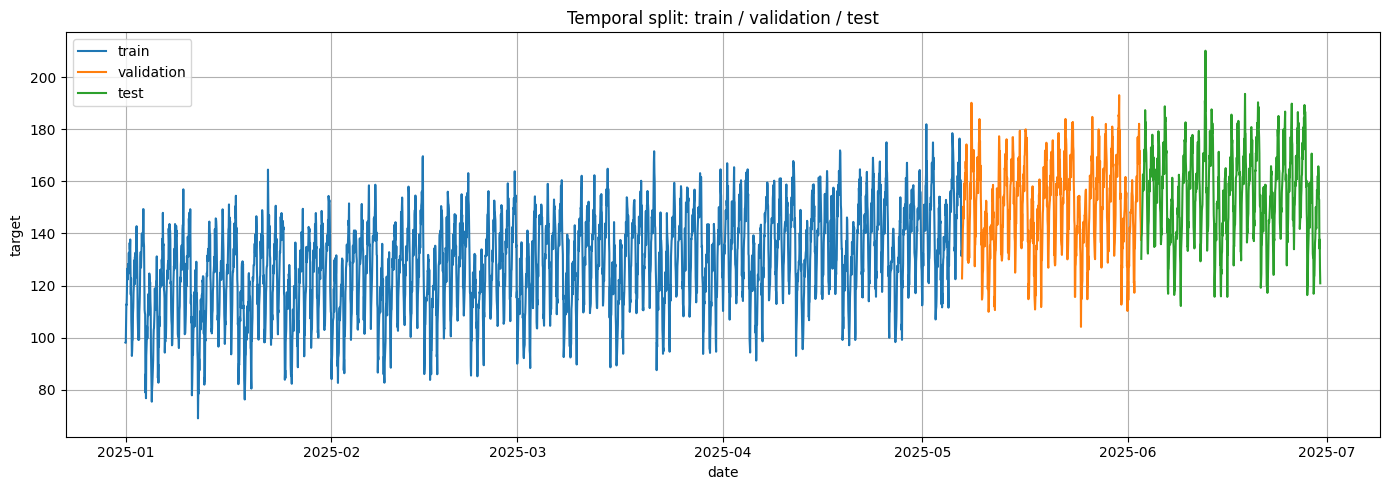

Saved: artifacts\figures\series_split.png


In [304]:
# Визуализация train / validation / test

plt.figure(figsize=(14, 5))
plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="validation")
plt.plot(test_df["date"], test_df["target"], label="test")
plt.title("Temporal split: train / validation / test")
plt.xlabel("date")
plt.ylabel("target")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(SERIES_SPLIT_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", SERIES_SPLIT_PATH)

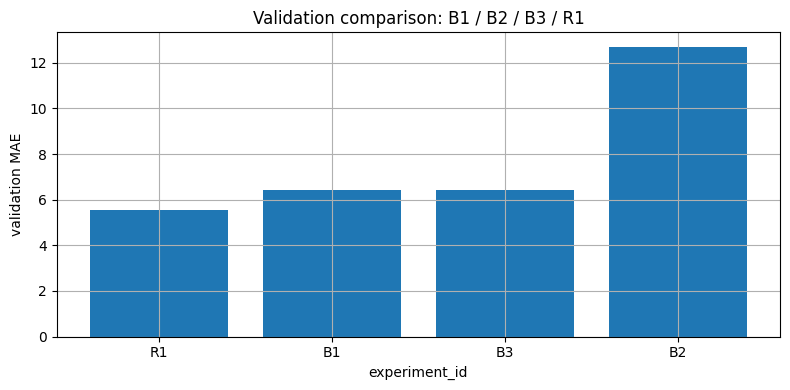

Saved: artifacts\figures\baselines_compare.png


In [305]:
# Сравнение B1 / B2 / B3 / R1 по validation MAE

plt.figure(figsize=(8, 4))
plt.bar(val_results["experiment_id"], val_results["MAE"])
plt.xlabel("experiment_id")
plt.ylabel("validation MAE")
plt.title("Validation comparison: B1 / B2 / B3 / R1")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(BASELINES_COMPARE_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", BASELINES_COMPARE_PATH)

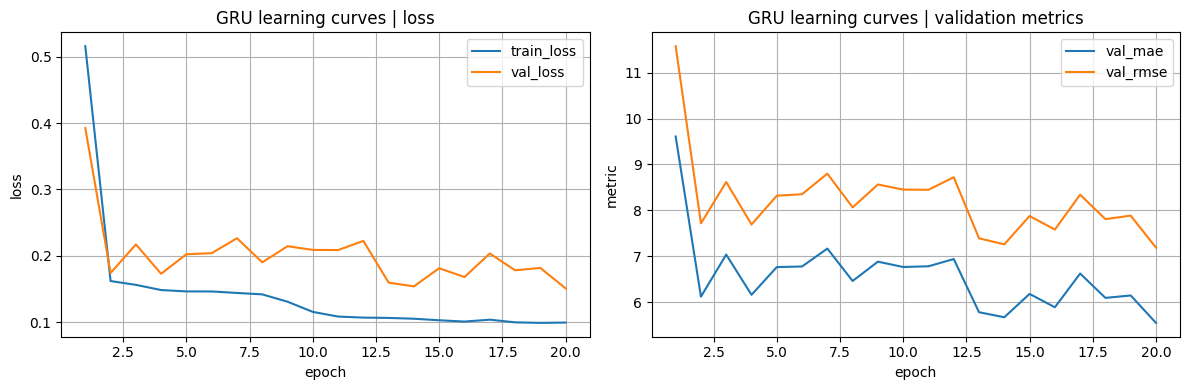

Saved: artifacts\figures\gru_learning_curves.png


In [306]:
# Кривые обучения GRU

epochs = list(range(1, len(gru_history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, gru_history["train_loss"], label="train_loss")
axes[0].plot(epochs, gru_history["val_loss"], label="val_loss")
axes[0].set_title("GRU learning curves | loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True)
axes[0].legend()
axes[1].plot(epochs, gru_history["val_mae"], label="val_mae")
axes[1].plot(epochs, gru_history["val_rmse"], label="val_rmse")
axes[1].set_title("GRU learning curves | validation metrics")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("metric")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig(GRU_LEARNING_CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", GRU_LEARNING_CURVES_PATH)

In [307]:
# Подготовка данных лучшей модели для графика test

if best_experiment_id == "B1":
    best_test_dates = test_feat["date"].to_numpy()
    best_test_true = test_true_b
    best_test_pred = test_pred_b1
elif best_experiment_id == "B2":
    best_test_dates = test_feat["date"].to_numpy()
    best_test_true = test_true_b
    best_test_pred = test_pred_b2
elif best_experiment_id == "B3":
    best_test_dates = test_feat["date"].to_numpy()
    best_test_true = test_true_b
    best_test_pred = test_pred_b3

elif best_experiment_id == "R1":
    best_test_dates = test_df["date"].iloc[window_size:].to_numpy()
    best_test_true = r1_test_true
    best_test_pred = r1_test_pred
else:
    raise ValueError(f"Unknown best_experiment_id: {best_experiment_id}")

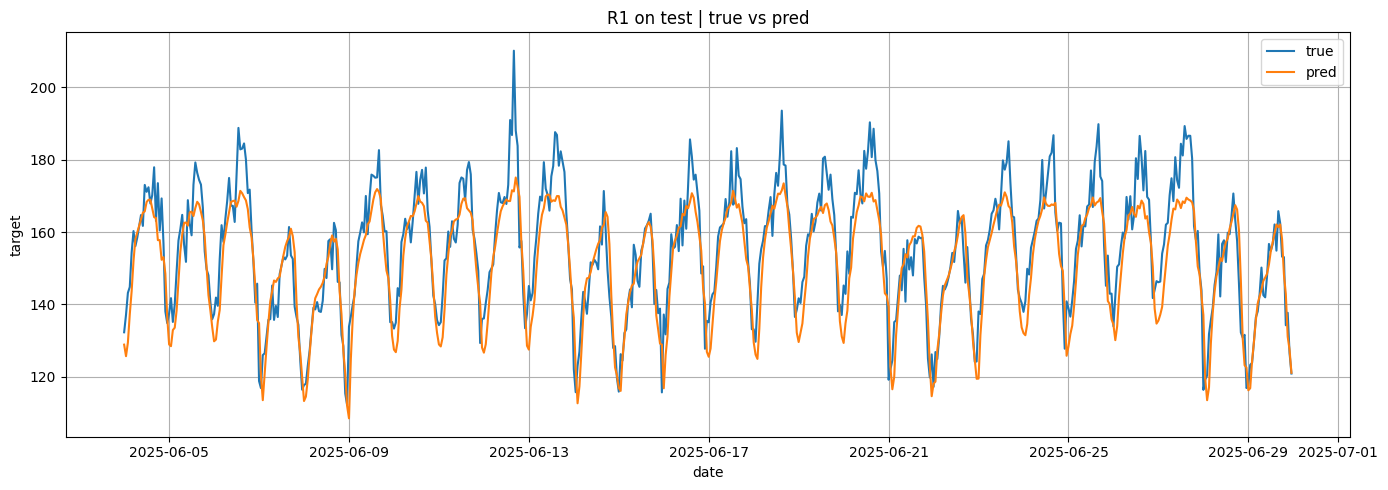

Saved: artifacts\figures\best_forecast_test.png


In [308]:
# График факта и прогноза лучшей модели на test

plt.figure(figsize=(14, 5))
plt.plot(best_test_dates, best_test_true, label="true")
plt.plot(best_test_dates, best_test_pred, label="pred")
plt.title(f"{best_experiment_id} on test | true vs pred")
plt.xlabel("date")
plt.ylabel("target")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(BEST_FORECAST_TEST_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", BEST_FORECAST_TEST_PATH)

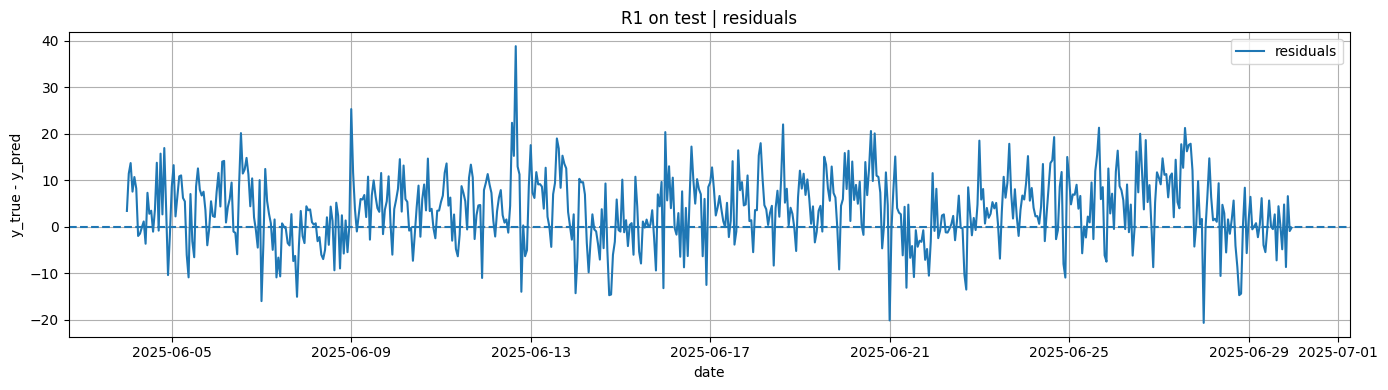

Saved: artifacts\figures\residuals_best.png


In [309]:
# График остатков лучшей модели

best_residuals = best_test_true - best_test_pred

plt.figure(figsize=(14, 4))
plt.plot(best_test_dates, best_residuals, label="residuals")
plt.axhline(0.0, linestyle="--")
plt.title(f"{best_experiment_id} on test | residuals")
plt.xlabel("date")
plt.ylabel("y_true - y_pred")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESIDUALS_BEST_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", RESIDUALS_BEST_PATH)

In [310]:
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("torch:", torch.__version__)

pandas: 3.0.1
numpy: 2.4.2
scikit-learn: 1.8.0
torch: 2.10.0+cpu
